In [37]:
import csv
import sklearn

## TASK 1 START: Load the dataset

In [38]:
with open('HappinessData-1.csv', mode='r', newline='', encoding='utf-8') as dataset:
    dataset_parser = csv.DictReader(dataset)
    data = list(dataset_parser)

## TASK 2 START: Reorder dataset columns

In [39]:
# The target feature (happy/unhappy) will be last column
columns = list(data[0].keys())
new_column_order = columns[1:] + [columns[0]]

# Reorder all datapoints
dataset_reordered = []
for row in data:
    # Create a dictionary following the new order
    reordered_row = {key: row[key] for key in new_column_order}
    dataset_reordered.append(reordered_row)

print("New Order:", list(dataset_reordered[0].keys()))

New Order: ['City Services Availability', 'Housing Cost', 'Quality of schools', 'Community trust in local police', 'Community Maintenance', 'Availability of Community Room ', 'Unhappy/Happy']


## TASK 3 START: Handle any missing/NA values

In [40]:
print(f"Pre-clean rows: {len(dataset_reordered)}")

clean_dataset = []
for row in data:
    # If any value is empty, drop row
    if any(value == '' or value is None for value in row.values()):
        continue # Skip this row
    # Otherwise we re-add row
    reordered_row = {key: row[key] for key in new_column_order}
    clean_dataset.append(reordered_row)
    
print(f"Post-clean rows: {len(clean_dataset)}")

Pre-clean rows: 140
Post-clean rows: 136


## TASK 4 START: Pearson Correlation

In [41]:
import math
import statistics

# Turn all nums into floats
numeric_data = [[float(val) for val in row.values()] for row in clean_dataset]

# Separate input features from target
X = [row[:-1] for row in numeric_data]
y = [row[-1] for row in numeric_data]

for i in range(len(X[0])):
    # Extract individual feature column
    feature_column = [row[i] for row in X]
    feature_name = new_column_order[i]
    
    # Calculate correlation between this feature and target feature
    r_value = statistics.correlation(feature_column, y)
    
    print(f"{feature_name}: {r_value:.4f}")

City Services Availability: 0.3304
Housing Cost: 0.0245
Quality of schools: 0.1766
Community trust in local police: 0.1234
Community Maintenance: 0.2146
Availability of Community Room : 0.2123


## TASK 5 START: Implement KNN without Scikit

In [42]:
split_pos = int(len(clean_dataset) * 0.8)

# We get our input features X (all features except happy/unhappy)
# We get our target feature Y (happy/unhappy)
X = []
y = []

# Use the Pearson Correlation from before to drop columns
for row in clean_dataset:
    all_features = list(row.values())[:-1]
    # Keep the columns below
    filtered_x = [
        float(all_features[0]), # City Services
        float(all_features[2]), # Quality of schools
        float(all_features[4]), # Community Maintenance
        float(all_features[5])  # Availability of Community Room
    ]
    X.append(filtered_x)

    y.append(int(list(row.values())[-1]))

# Make the train/set sets using the split position
X_train, X_test = X[:split_pos], X[split_pos:]
y_train, y_test = y[:split_pos], y[split_pos:]

print(f"Training set: {len(X_train)} rows")
print(f"Testing set: {len(X_test)} rows")

Training set: 108 rows
Testing set: 28 rows


In [43]:
# Normalize features so they all fall between 0-1
mins = [min(column) for column in zip(*X_train)]
maxs = [max(column) for column in zip(*X_train)]

def normalize_dataset(dataset, mins, maxs):
    normalized_data = []
    for row in dataset:
        new_row = []
        for i in range(len(row)):
            denom = float(maxs[i]) - float(mins[i])
            scaled_val = (float(row[i]) - float(mins[i])) / denom
            new_row.append(scaled_val)
        normalized_data.append(new_row)
    return normalized_data

# Apply normalization to both sets
X_train_norm = normalize_dataset(X_train, mins, maxs)
X_test_norm = normalize_dataset(X_test, mins, maxs)

In [44]:
# Function to find k nearest neighbors gets majority vote
def predict_classification(train_X, train_y, test_row, k, distance_func):
    distances = []
    # Calculate distance to every other row (datapoint)
    for i in range(len(train_X)):
        dist = distance_func(test_row, train_X[i])
        distances.append((train_y[i], dist))
    
    # Sort by distance
    distances.sort(key=lambda x: x[1])
    
    # Get the labels of the top k neighbors
    neighbors_labels = [distances[i][0] for i in range(k)]
    
    # Return the most common label (the "mode")
    return statistics.mode(neighbors_labels)

In [45]:
# First distance metric we use is Euclidean
def euclidean(row1, row2):
    distance = 0.0
    for i in range(len(row1)):
        distance += (float(row1[i]) - float(row2[i]))**2
    return math.sqrt(distance)

# Second distance metric is Manhattan
def manhattan(row1, row2):
    distance = 0.0
    for i in range(len(row1)):
        # Sum of absolute differences instead of squared differences
        distance += abs(float(row1[i]) - float(row2[i]))
    return distance

In [46]:
k = 3
predictions = []

# EUCLIDEAN TEST
for row in X_test_norm:
    result = predict_classification(X_train_norm, y_train, row, k, euclidean)
    predictions.append(result)

# Calculate accuracy
correct = 0
for i in range(len(y_test)):
    if y_test[i] == predictions[i]:
        correct += 1

accuracy = (correct / len(y_test))
print(f"knn Accuracy (k={k}): {accuracy:.2%}")

# Off testing:
# Best k-value is 3 with accuracy of 75%

knn Accuracy (k=3): 75.00%


In [47]:
k = 3
predictions = []

# MANHATTAN TEST
for row in X_test_norm:
    result = predict_classification(X_train_norm, y_train, row, k, manhattan)
    predictions.append(result)

# Calculate accuracy
correct = 0
for i in range(len(y_test)):
    if y_test[i] == predictions[i]:
        correct += 1

accuracy = (correct / len(y_test))
print(f"knn Accuracy (k={k}): {accuracy:.2%}")

# Off testing:
# Best k-value is 3 with accuracy of 75%

knn Accuracy (k=3): 75.00%


## TASK 6 START: Doing KNN using Scikit

In [50]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

k_sklearn = 5

# --------- MANHATTAN -------------

# Initialize the Scikit KNN model
knn_model = KNeighborsClassifier(n_neighbors=k_sklearn, metric='manhattan')

# Train the model using the same normalized set as earlier
knn_model.fit(X_train_norm, y_train)

# Make predictions on your testing lists
sklearn_predictions = knn_model.predict(X_test_norm)

# Calculate and print the accuracy
sklearn_accuracy = accuracy_score(y_test, sklearn_predictions)
print(f"Scikit-Learn KNN Accuracy Manhattan (k={k_sklearn}): {sklearn_accuracy:.2%}")

# --------- EUCLIDEAN -------------

# Now we use euclidean distance
knn_model = KNeighborsClassifier(n_neighbors=k_sklearn, metric='euclidean')

# Train the model using the same normalized set as earlier
knn_model.fit(X_train_norm, y_train)

# Make predictions on your testing lists
sklearn_predictions = knn_model.predict(X_test_norm)

# Calculate and print the accuracy
sklearn_accuracy = accuracy_score(y_test, sklearn_predictions)
print(f"Scikit-Learn KNN Accuracy Euclidean (k={k_sklearn}): {sklearn_accuracy:.2%}")


# Best for both euclidean & manhattan seems to be:
# k = 5 with accuracy of 64.29%

Scikit-Learn KNN Accuracy Manhattan (k=5): 64.29%
Scikit-Learn KNN Accuracy Euclidean (k=5): 64.29%


## TASK 7 START: Iterating over K values

In [56]:
# These will hold the k-values we iterate over and their accuracy.
# For example, if k = 3 is 60%, then index 2 will be 60%.
k_list_no_scikit = []
k_list_scikit = []

# We will be using EUCLIDEAN distance for both tests

# Let's fill k_list for Scikit KNN first
for k in range(1, 51):
    # Code copied from Task 6 above
    knn_model = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
    knn_model.fit(X_train_norm, y_train)
    sklearn_predictions = knn_model.predict(X_test_norm)
    sklearn_accuracy = accuracy_score(y_test, sklearn_predictions)
    k_list_scikit.append(sklearn_accuracy)

# Now we use the self-made KNN from Task 5
for k in range(1, 51):
    # Code copied from Task 5
    predictions = []
    for row in X_test_norm:
        result = predict_classification(X_train_norm, y_train, row, k, euclidean)
        predictions.append(result)
    correct = 0
    for i in range(len(y_test)):
        if y_test[i] == predictions[i]:
            correct += 1
    accuracy = (correct / len(y_test))
    k_list_no_scikit.append(accuracy)

print(f"        No Scikit / Scikit")
for i in range(0, 50):
    print(f"k = {i + 1} | {k_list_no_scikit[i]:.4f}%, {k_list_scikit[i]:.4f}%")
    


        No Scikit / Scikit
k = 1 | 0.5714%, 0.7143%
k = 2 | 0.5714%, 0.6429%
k = 3 | 0.7500%, 0.5357%
k = 4 | 0.5714%, 0.6071%
k = 5 | 0.6071%, 0.6429%
k = 6 | 0.5714%, 0.6071%
k = 7 | 0.5714%, 0.6071%
k = 8 | 0.4643%, 0.5357%
k = 9 | 0.5357%, 0.5357%
k = 10 | 0.4643%, 0.5714%
k = 11 | 0.4643%, 0.4643%
k = 12 | 0.3929%, 0.5714%
k = 13 | 0.3571%, 0.5714%
k = 14 | 0.3571%, 0.5714%
k = 15 | 0.4643%, 0.5357%
k = 16 | 0.4643%, 0.5714%
k = 17 | 0.5000%, 0.5357%
k = 18 | 0.5000%, 0.5357%
k = 19 | 0.4286%, 0.5357%
k = 20 | 0.4643%, 0.5714%
k = 21 | 0.5000%, 0.6071%
k = 22 | 0.4643%, 0.5714%
k = 23 | 0.4286%, 0.4643%
k = 24 | 0.4286%, 0.4643%
k = 25 | 0.4286%, 0.3929%
k = 26 | 0.5000%, 0.4286%
k = 27 | 0.5000%, 0.4286%
k = 28 | 0.5000%, 0.4286%
k = 29 | 0.5000%, 0.4643%
k = 30 | 0.4643%, 0.4286%
k = 31 | 0.5000%, 0.5000%
k = 32 | 0.5714%, 0.5000%
k = 33 | 0.5357%, 0.4643%
k = 34 | 0.5357%, 0.5000%
k = 35 | 0.5000%, 0.5357%
k = 36 | 0.5357%, 0.5357%
k = 37 | 0.5357%, 0.5000%
k = 38 | 0.5000%, 0.

## TASK 8 START: Plot the error rate for both KNN algos

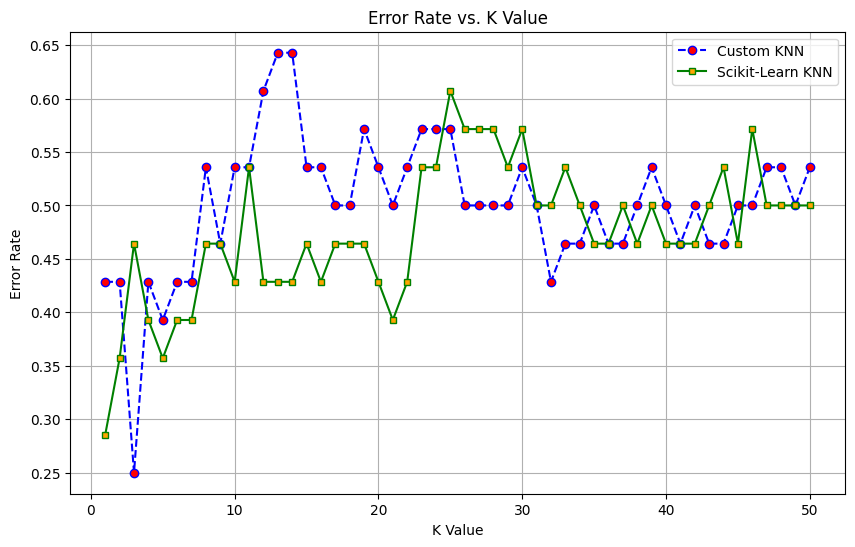

In [55]:
# We need matplotlib to make a graph
import matplotlib.pyplot as plt

# Convert accuracy to error (error = 1 - accuracy)
error_rate_no_scikit = [(1 - acc) for acc in k_list_no_scikit]
error_rate_scikit = [(1 - acc) for acc in k_list_scikit]

# K values we used above
k_values = range(1, 51)

# Set up the figure size
plt.figure(figsize=(10, 6))

# Plot the custom KNN algorithm error rate
plt.plot(k_values, error_rate_no_scikit, color='blue', linestyle='dashed', 
         marker='o', markerfacecolor='red', markersize=6, label='Custom KNN')

# Plot the Scikit-Learn error rate so we can compare
plt.plot(k_values, error_rate_scikit, color='green', linestyle='solid', 
         marker='s', markerfacecolor='orange', markersize=5, label='Scikit-Learn KNN')

# Label the graph
plt.title('Error Rate vs. K Value')
plt.xlabel('K Value')
plt.ylabel('Error Rate')
plt.legend()
plt.grid(True)

# Display the plot
plt.show()

## TASK 9 START: N-Fold Cross Validation

In [ ]:
# N will determine number of folds
n = 10

